In [3]:
import pandas as pd

df = pd.read_csv("shopping_trends.csv")

print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

In [4]:
df.shape

(3900, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [6]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Credit Card,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,696,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [7]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [8]:
df.columns= df.columns.str.lower()
df.columns= df.columns.str.replace(" ", "_")

print(df.columns)

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'payment_method',
       'shipping_type', 'discount_applied', 'promo_code_used',
       'previous_purchases', 'preferred_payment_method',
       'frequency_of_purchases'],
      dtype='object')


In [9]:
df.rename(columns={'purchase_amount_(usd)':"purchase_amount"}, inplace=True)
print(df.columns)

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'payment_method',
       'shipping_type', 'discount_applied', 'promo_code_used',
       'previous_purchases', 'preferred_payment_method',
       'frequency_of_purchases'],
      dtype='object')


In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3895    False
3896    False
3897    False
3898    False
3899    False
Length: 3900, dtype: bool

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['age_group'] = pd.cut(df['age'],
                        bins=[0,18,30,45,60,100],
                        labels=['Teen','Young','Adult','Mid-Age','Senior'])

In [13]:
df['spending_level'] = df['purchase_amount'].apply(
    lambda x: 'High' if x > df['purchase_amount'].mean() else 'Low'
)

In [14]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'payment_method',
       'shipping_type', 'discount_applied', 'promo_code_used',
       'previous_purchases', 'preferred_payment_method',
       'frequency_of_purchases', 'age_group', 'spending_level'],
      dtype='object')

In [15]:
df.head(5)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,subscription_status,payment_method,shipping_type,discount_applied,promo_code_used,previous_purchases,preferred_payment_method,frequency_of_purchases,age_group,spending_level
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,Mid-Age,Low
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,Young,High
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Mid-Age,High
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young,High
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,Adult,Low


In [16]:
df['purchase_amount'].sum()

np.int64(233081)

In [17]:
df.groupby("category")["purchase_amount"].sum().sort_values(ascending=False)

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64

In [18]:
df.groupby("gender")["purchase_amount"].sum()

gender
Female     75191
Male      157890
Name: purchase_amount, dtype: int64

In [19]:
df.groupby("payment_method")["purchase_amount"].sum()

payment_method
Bank Transfer    37123
Cash             38833
Credit Card      42567
Debit Card       37118
PayPal           37449
Venmo            39991
Name: purchase_amount, dtype: int64

In [20]:
df.groupby("subscription_status")["purchase_amount"].sum()

subscription_status
No     170436
Yes     62645
Name: purchase_amount, dtype: int64

In [21]:
df.groupby("age_group")["purchase_amount"].sum()

C:\Users\vaish\AppData\Local\Temp\ipykernel_708\1596394312.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["purchase_amount"].sum()


age_group
Teen        4139
Young      53140
Adult      64927
Mid-Age    67711
Senior     43164
Name: purchase_amount, dtype: int64

In [22]:
df.groupby("spending_level")["gender"].count()

spending_level
High    1963
Low     1937
Name: gender, dtype: int64

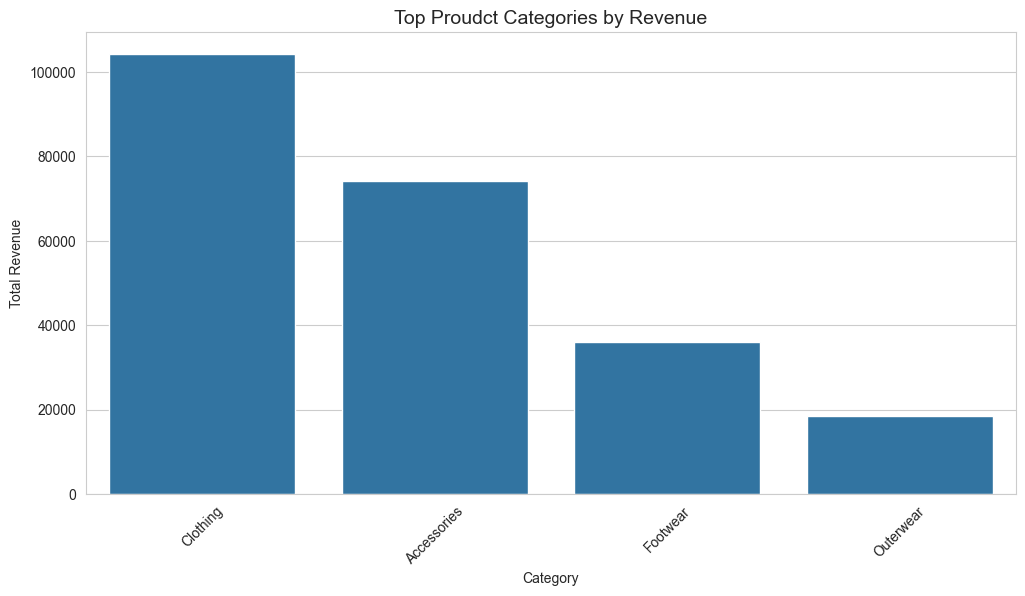

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

category_sales= df.groupby("category")["purchase_amount"].sum().sort_values(ascending= False)
sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Top Proudct Categories by Revenue", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

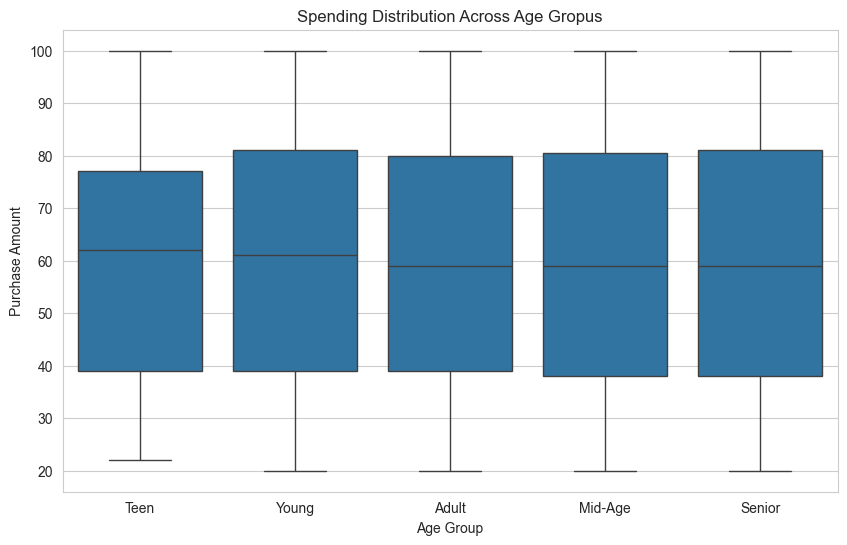

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(x="age_group", y="purchase_amount", data=df)

plt.title("Spending Distribution Across Age Gropus")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")

plt.show()

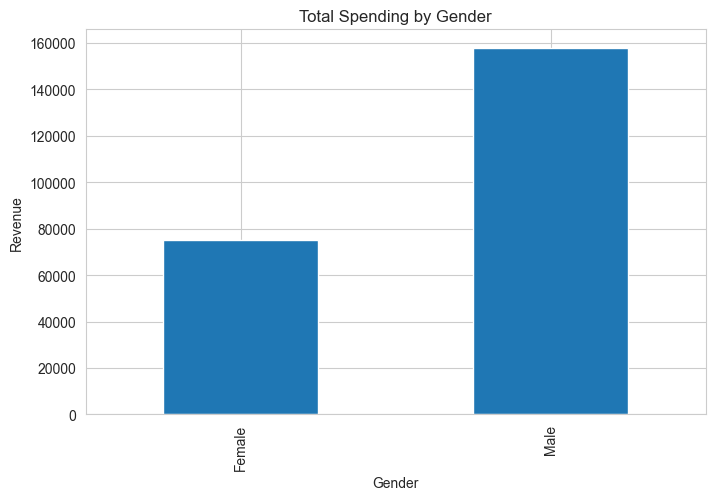

In [25]:
plt.figure(figsize=(8,5))

gender_sales = df.groupby('gender')['purchase_amount'].sum()

gender_sales.plot(kind='bar')

plt.title("Total Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")

plt.show()

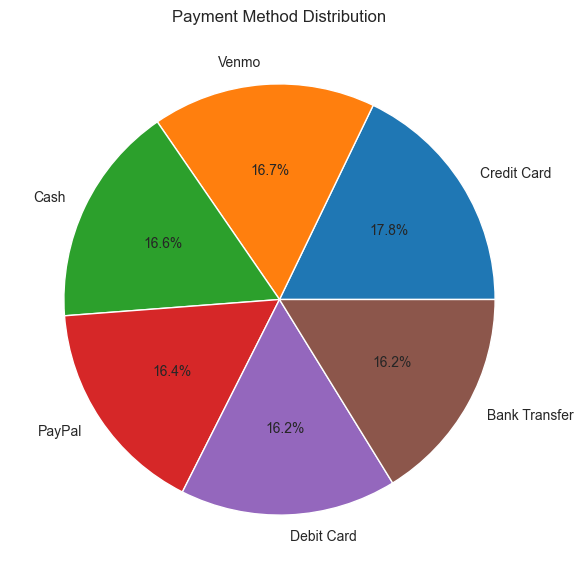

In [26]:
plt.figure(figsize=(7,7))

payment = df['payment_method'].value_counts()

plt.pie(payment, labels=payment.index, autopct='%1.1f%%')
plt.title("Payment Method Distribution")

plt.show()

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='Spending_Level', data=df)

plt.title("High vs Low Spending Customers")

plt.show()

ValueError: Could not interpret value `Spending_Level` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

C:\Users\vaish\AppData\Local\Temp\ipykernel_11600\2782028000.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='purchase_amount',


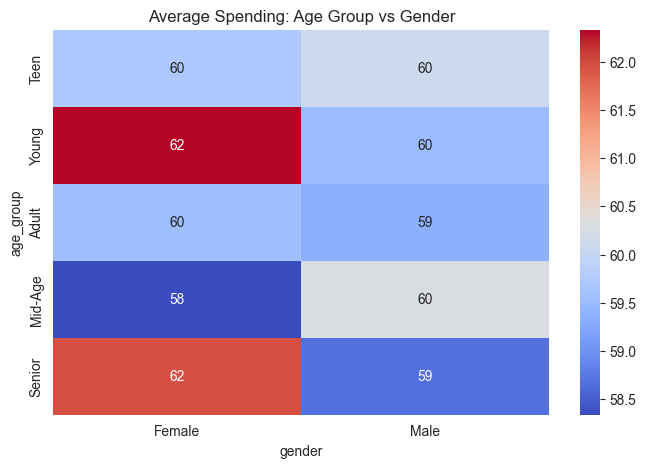

In [ ]:
plt.figure(figsize=(8,5))

pivot = df.pivot_table(values='purchase_amount',
                       index='age_group',
                       columns='gender',
                       aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')

plt.title("Average Spending: Age Group vs Gender")

plt.show()

In [28]:
df.to_csv("cleaned_sales_data.csv", index=False)

In [29]:
import sqlite3
import pandas as pd

# connect to database
conn = sqlite3.connect("sales.db")

# load cleaned data
df = pd.read_csv("cleaned_sales_data.csv")

# send data to SQL table
df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database created and data inserted!")

Database created and data inserted!


In [30]:
pd.read_sql("SELECT * FROM sales LIMIT 5", conn)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,subscription_status,payment_method,shipping_type,discount_applied,promo_code_used,previous_purchases,preferred_payment_method,frequency_of_purchases,age_group,spending_level
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,Mid-Age,Low
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,Young,High
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Mid-Age,High
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young,High
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,Adult,Low


In [33]:
query = "SELECT SUM(Purchase_Amount) AS Total_Revenue FROM sales"
pd.read_sql(query, conn)

,Total_Revenue
0,233081


In [32]:
query = """
SELECT Category, SUM(Purchase_Amount) AS Revenue
FROM sales
GROUP BY Category
ORDER BY Revenue DESC
"""
pd.read_sql(query, conn)

,category,Revenue
0,Clothing,104264
1,Accessories,74200
2,Footwear,36093
3,Outerwear,18524


clothing category generates the highest revenue, indicating strong customer demand.

In [34]:
query = """
SELECT Gender, SUM(Purchase_Amount) AS Total_Spending
FROM sales
GROUP BY Gender
"""
pd.read_sql(query, conn)

,gender,Total_Spending
0,Female,75191
1,Male,157890


male customers contribute slightly higher total spending compared to females.

In [35]:
query = """
SELECT Payment_Method, COUNT(*) AS Transactions
FROM sales
GROUP BY Payment_Method
ORDER BY Transactions DESC
"""
pd.read_sql(query, conn)

,payment_method,Transactions
0,Credit Card,696
1,Venmo,653
2,Cash,648
3,PayPal,638
4,Debit Card,633
5,Bank Transfer,632


Digital payment methods are most preferred, showing shift towards cashless transactions.

In [36]:
query = """
SELECT Age_Group, AVG(Purchase_Amount) AS Avg_Spending
FROM sales
GROUP BY Age_Group
ORDER BY Avg_Spending DESC
"""
pd.read_sql(query, conn)

,age_group,Avg_Spending
0,Young,60.386364
1,Teen,59.985507
2,Senior,59.701245
3,Mid-Age,59.657269
4,Adult,59.402562


Young age group shows the highest average spending, making them key target customers.

In [37]:
query = """
SELECT Spending_Level, COUNT(*) AS Customers
FROM sales
GROUP BY Spending_Level
"""
pd.read_sql(query, conn)

,spending_level,Customers
0,High,1963
1,Low,1937


high and low spending customers are almost equally distributed, indicating a balanced customer base with no extreme skew.

In [38]:
query = """
SELECT Customer_ID, SUM(Purchase_Amount) AS Total_Spent
FROM sales
GROUP BY Customer_ID
ORDER BY Total_Spent DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,customer_id,Total_Spent
0,3838,100
1,3726,100
2,3322,100
3,3266,100
4,3029,100


Top customers have a similar spending levels, suggesting no single dominant customer and a fairly uniform high-value segment.

In [40]:
query = """
SELECT Payment_Method, AVG(Purchase_Amount) AS Avg_Spending
FROM sales
GROUP BY Payment_Method
ORDER BY Avg_Spending DESC
"""
pd.read_sql(query, conn)

,payment_method,Avg_Spending
0,Venmo,61.241960
1,Credit Card,61.159483
2,Cash,59.927469
3,Bank Transfer,58.738924
4,PayPal,58.697492
5,Debit Card,58.638231


customers using digital payment methods like venmo and credit cards show slightly higher average spending compared to cash users.

In [42]:
query = """
SELECT Category, COUNT(*) AS Purchase_Count
FROM sales
GROUP BY Category
ORDER BY Purchase_Count DESC
"""
pd.read_sql(query, conn)

,category,Purchase_Count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


clothing is the most frequently purchased category, indicating highest customer demand, while outerwear has the lowest purchase frequency.

In [39]:
query = """
SELECT 
    CASE 
        WHEN Previous_Purchases > 5 THEN 'Loyal'
        ELSE 'New'
    END AS Customer_Type,
    COUNT(*) AS Total_Customers
FROM sales
GROUP BY Customer_Type
"""
pd.read_sql(query, conn)

,Customer_Type,Total_Customers
0,Loyal,3476
1,New,424


a large majoeity of customers are loyal, showing strong customer retention and repeat purchasing behavior.

In [44]:
query = """
SELECT Discount_Applied, AVG(Purchase_Amount) AS Avg_Spending
FROM sales
GROUP BY Discount_Applied
"""
pd.read_sql(query, conn)

,discount_applied,Avg_Spending
0,No,60.130454
1,Yes,59.279070


average spending is slightly higher without discounts, suggesting discounts do not significantly increase purchase value.

In [45]:
query = """
SELECT Gender, Category, SUM(Purchase_Amount) AS Revenue
FROM sales
GROUP BY Gender, Category
ORDER BY Gender, Revenue DESC
"""
pd.read_sql(query, conn)

,gender,category,Revenue
0,Female,Clothing,33636
1,Female,Accessories,23819
2,Female,Footwear,11835
3,Female,Outerwear,5901
4,Male,Clothing,70628
5,Male,Accessories,50381
6,Male,Footwear,24258
7,Male,Outerwear,12623


male  customers contribute higher revenue across all categories, with clothing being the top-performing category for both genders.

In [46]:
result = pd.read_sql(query, conn)
result.to_csv("category_analysis.csv", index=False)